In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input

In [4]:
dataset_path = "data/UTKFace"

filepaths = []
ages = []

for img_name in os.listdir(dataset_path):
    try:
        age = int(img_name.split("_")[0])

        filepaths.append(os.path.join(dataset_path, img_name))
        ages.append(age)
    except:
        continue

df = pd.DataFrame({
    'filename': filepaths,
    'age': ages
})

print("Total images:", len(df))
print(df.head())

Total images: 23708
                                            filename  age
0  data/UTKFace\100_0_0_20170112213500903.jpg.chi...  100
1  data/UTKFace\100_0_0_20170112215240346.jpg.chi...  100
2  data/UTKFace\100_1_0_20170110183726390.jpg.chi...  100
3  data/UTKFace\100_1_0_20170112213001988.jpg.chi...  100
4  data/UTKFace\100_1_0_20170112213303693.jpg.chi...  100


In [5]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 16595
Val: 3556
Test: 3557


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='age',
    target_size=(224,224),
    batch_size=32,
    class_mode='raw'
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='age',
    target_size=(224,224),
    batch_size=32,
    class_mode='raw'
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='age',
    target_size=(224,224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

Found 16595 validated image filenames.
Found 3556 validated image filenames.
Found 3557 validated image filenames.


In [7]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [8]:
for layer in base_model.layers:
    layer.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

In [10]:
model.compile(
    optimizer=Adam(0.001),
    loss='mse',
    metrics=['mae']
)

In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1224s 2s/step - loss: 182.4045 - mae: 9.9936 - val_loss: 140.9648 - val_mae: 9.2028
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1000s 2s/step - loss: 124.0222 - mae: 8.2803 - val_loss: 108.6920 - val_mae: 7.6506
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 935s 2s/step - loss: 117.6754 - mae: 8.0199 - val_loss: 104.4469 - val_mae: 7.5419
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 949s 2s/step - loss: 113.9526 - mae: 7.8705 - val_loss: 103.3542 - val_mae: 7.4399
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 951s 2s/step - loss: 111.1244 - mae: 7.7965 - val_loss: 103.5045 - val_mae: 7.5878


In [12]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='mse',
    metrics=['mae']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3
)

Epoch 1/3
519/519 ━━━━━━━━━━━━━━━━━━━━ 1463s 3s/step - loss: 134.4162 - mae: 8.7274 - val_loss: 105.5829 - val_mae: 7.4781
Epoch 2/3
519/519 ━━━━━━━━━━━━━━━━━━━━ 1446s 3s/step - loss: 102.7484 - mae: 7.5876 - val_loss: 89.1306 - val_mae: 6.8903
Epoch 3/3
519/519 ━━━━━━━━━━━━━━━━━━━━ 1444s 3s/step - loss: 88.7639 - mae: 7.0587 - val_loss: 85.1290 - val_mae: 6.7927


In [13]:
test_loss, test_mae = model.evaluate(test_gen)

print("Test MAE:", test_mae)

112/112 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - loss: 82.0847 - mae: 6.6877
Test MAE: 6.687681674957275


In [14]:
preds = model.predict(test_gen).flatten()
true_ages = test_df['age'].values

112/112 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step


In [15]:
def age_to_range(age):
    if age <= 12:
        return "Child"
    elif age <= 19:
        return "Teen"
    elif age <= 30:
        return "Young Adult"
    elif age <= 45:
        return "Adult"
    elif age <= 60:
        return "Middle Age"
    else:
        return "Senior"

In [16]:
for i in range(10):
    print("Real:", int(true_ages[i]), "| Pred:", int(preds[i]))
    print("Real Range:", age_to_range(true_ages[i]),
          "| Pred Range:", age_to_range(preds[i]))
    print("------")

Real: 24 | Pred: 30
Real Range: Young Adult | Pred Range: Adult
------
Real: 67 | Pred: 50
Real Range: Senior | Pred Range: Middle Age
------
Real: 30 | Pred: 30
Real Range: Young Adult | Pred Range: Adult
------
Real: 50 | Pred: 37
Real Range: Middle Age | Pred Range: Adult
------
Real: 26 | Pred: 42
Real Range: Young Adult | Pred Range: Adult
------
Real: 1 | Pred: 1
Real Range: Child | Pred Range: Child
------
Real: 65 | Pred: 62
Real Range: Senior | Pred Range: Senior
------
Real: 23 | Pred: 28
Real Range: Young Adult | Pred Range: Young Adult
------
Real: 51 | Pred: 52
Real Range: Middle Age | Pred Range: Middle Age
------
Real: 32 | Pred: 34
Real Range: Adult | Pred Range: Adult
------


In [17]:
correct = 0

for i in range(len(preds)):
    if age_to_range(preds[i]) == age_to_range(true_ages[i]):
        correct += 1

range_acc = correct / len(preds)

print("Range Accuracy:", range_acc)

Range Accuracy: 0.5931965139162215


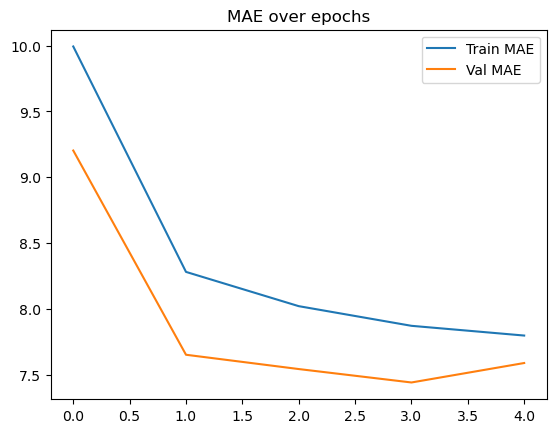

In [18]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend()
plt.title("MAE over epochs")
plt.show()